# Laboratorio práctico de ETL — Kaismart Solutions S.A.S.
**Universidad Autónoma de Occidente** · Metodología **Medallion** (Bronze → Silver → Gold)

**Autor:** Juan Sebastián Sánchez Urbano · juan_s.sanchez_u@uao.edu.co · Maestría en Ciencia de Datos e IA (más integrantes en `config.yaml`).  Fuentes: MySQL `clientes.ventas` (5.000 registros) y `kaismart_eventos_logisticos.xlsx` (50.000 eventos), unidas por `pedido_id`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
sys.path.insert(0, os.path.abspath(".."))      # para importar el paquete etl/ desde notebooks/
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from etl.config import cargar_config, ruta, RAIZ
from etl import profiling as pf
from etl.transform import Decisiones, silver_ventas, silver_logistica, gold_pedidos, ORDEN_ESTADOS

pd.set_option("display.max_columns", 50); pd.set_option("display.width", 220)
cfg = cargar_config()
print("Autores:", cfg["autores"])

Autores: ['Juan Sebastián Sánchez Urbano']


## PARTE 1 — Extracción desde MySQL (Bronze)

In [2]:
# 1) librerías  2) conexión  3-4) consulta de toda la tabla  5) DataFrame  7) cierre de la conexión
m = cfg["mysql"]
conn = None
try:
    import mysql.connector
    conn = mysql.connector.connect(host=m["host"], user=m["user"], password=m["password"], database=m["database"])
    df_ventas = pd.read_sql("SELECT * FROM ventas", conn)
except Exception as e:                      # plan B opcional: CSV exportado (config.yaml -> ventas_csv_respaldo)
    if not cfg.get("ventas_csv_respaldo"): raise
    print("MySQL no disponible, usando respaldo:", e); df_ventas = pd.read_csv(RAIZ / cfg["ventas_csv_respaldo"])
finally:
    if conn is not None and conn.is_connected():
        conn.close(); print("Conexión cerrada")

Conexión cerrada


In [3]:
# 6) comprobación
print(df_ventas.shape); print(list(df_ventas.columns)); display(df_ventas.head()); display(df_ventas.sample(5, random_state=42))

(5000, 17)
['id_venta', 'pedido_id', 'fecha_venta', 'id_cliente', 'ciudad', 'canal', 'id_tienda', 'categoria', 'producto', 'cantidad', 'precio_unitario', 'descuento_pct', 'valor_bruto', 'valor_descuento', 'valor_neto', 'medio_pago', 'calificacion_cliente']


,id_venta,pedido_id,fecha_venta,id_cliente,ciudad,canal,id_tienda,categoria,producto,cantidad,precio_unitario,descuento_pct,valor_bruto,valor_descuento,valor_neto,medio_pago,calificacion_cliente
0,1,PED000001,2026-01-18 22:06:15,CLI00011,Bogotá D.C.,Aplicación móvil,NaN,Deportes,Banda caminadora,1,2199900.0,10.0,2199900.0,219990.0,1979910.0,Tarjeta crédito,NaN
1,2,PED000002,2026-04-25 21:07:01,CLI00802,Cali,Página web,NaN,Deportes,Mancuernas ajustables,1,399900.0,10.0,399900.0,39990.0,359910.0,Tarjeta crédito,NaN
2,3,PED000003,2026-03-28 02:39:43,CLI00255,Medellín,Página web,NaN,Tecnología,Tablet 10 pulgadas,1,899900.0,10.0,899900.0,89990.0,809910.0,Tarjeta crédito,4.0
3,4,PED000004,2026-04-30 12:35:40,CLI00383,Medellín,Aplicación móvil,NaN,Electrodomésticos,Freidora de aire,2,472400.0,15.0,944800.0,141720.0,803080.0,PSE,5.0
4,5,PED000005,2026-04-04 00:18:12,CLI01286,Bogotá D.C.,Aplicación móvil,NaN,Deportes,Balón fútbol,1,119900.0,0.0,119900.0,0.0,119900.0,Tarjeta crédito,NaN


,id_venta,pedido_id,fecha_venta,id_cliente,ciudad,canal,id_tienda,categoria,producto,cantidad,precio_unitario,descuento_pct,valor_bruto,valor_descuento,valor_neto,medio_pago,calificacion_cliente
1501,1502,PED001502,2026-06-10 08:36:33,CLI02390,Bucaramanga,Tienda física,BGA-01,Tecnología,Monitor 24 pulgadas,2,713900.0,5.0,1427800.0,71390.0,1356410.0,Tarjeta débito,NaN
2586,2587,PED002587,2026-05-09 09:23:12,CLI01262,Bucaramanga,Aplicación móvil,NaN,Tecnología,Audífonos Bluetooth,2,149900.0,5.0,299800.0,14990.0,284810.0,Billetera digital,4.0
2653,2654,PED002654,2026-05-20 23:03:48,CLI01371,Cali,Aplicación móvil,NaN,Oficina,Base para portátil,1,112100.0,0.0,112100.0,0.0,112100.0,Tarjeta crédito,NaN
1055,1056,PED001056,2026-03-18 19:24:39,CLI00437,Medellín,Tienda física,MDE-01,Deportes,Bicicleta estática,2,1499900.0,0.0,2999800.0,0.0,2999800.0,Efectivo,5.0
705,706,PED000706,2026-06-06 19:01:06,CLI01135,Bogotá D.C.,Página web,NaN,Tecnología,Teclado mecánico,1,229900.0,5.0,229900.0,11495.0,218405.0,PSE,NaN


## PARTE 2 — Extracción desde Excel (Bronze)

In [4]:
df_logistica = pd.read_excel(RAIZ / cfg["excel"]["ruta"], sheet_name=cfg["excel"]["hoja"])
print(df_logistica.shape); print(list(df_logistica.columns)); display(df_logistica.head()); display(df_logistica.sample(5, random_state=42))

(50000, 14)
['evento_id', 'pedido_id', 'fecha_evento', 'estado_evento', 'centro_logistico', 'ciudad_destino', 'transportadora', 'numero_guia', 'fecha_prometida_entrega', 'tiempo_etapa_horas', 'costo_envio', 'incidencia', 'observacion', 'Unnamed: 13']


,evento_id,pedido_id,fecha_evento,estado_evento,centro_logistico,ciudad_destino,transportadora,numero_guia,fecha_prometida_entrega,tiempo_etapa_horas,costo_envio,incidencia,observacion,Unnamed: 13
0,1,PED000001,2026-01-18 22:06:15,Pedido recibido,CEDI Bogotá,Bogotá D.C.,NaN,NaN,2026-01-20 14:06:15,NaN,8900,NaN,NaN,"=AI("""")"
1,2,PED000001,2026-01-18 22:36:53,Pago aprobado,CEDI Bogotá,Bogotá D.C.,NaN,NaN,2026-01-20 14:06:15,0.51,8900,NaN,NaN,NaN
2,3,PED000001,2026-01-18 23:31:22,Orden enviada a logística,CEDI Bogotá,Bogotá D.C.,NaN,NaN,2026-01-20 14:06:15,0.91,8900,NaN,NaN,NaN
3,4,PED000001,2026-01-19 02:03:55,En alistamiento,CEDI Bogotá,Bogotá D.C.,NaN,NaN,2026-01-20 14:06:15,2.54,8900,NaN,NaN,NaN
4,5,PED000001,2026-01-19 06:14:51,Empacado,CEDI Bogotá,Bogotá D.C.,NaN,NaN,2026-01-20 14:06:15,4.18,8900,NaN,NaN,NaN


,evento_id,pedido_id,fecha_evento,estado_evento,centro_logistico,ciudad_destino,transportadora,numero_guia,fecha_prometida_entrega,tiempo_etapa_horas,costo_envio,incidencia,observacion,Unnamed: 13
33553,33554,PED003356,2026-04-04 09:51:57,En alistamiento,CEDI Pereira,Pereira,NaN,NaN,2026-04-06 02:08:22,1.78,9900,NaN,Pedido procesado dentro de la ventana prevista.,NaN
9427,9428,PED000943,2026-04-14 11:09:42,En tránsito,CEDI Bucaramanga,Bucaramanga,Servientrega,KMS77388424,2026-04-15 16:24:14,9.56,8900,NaN,NaN,NaN
199,200,PED000020,2026-02-08 21:23:51,Entregado,CEDI Bogotá,Bogotá D.C.,TCC,KMS46254024,2026-02-09 11:26:46,5.13,13900,NaN,NaN,NaN
12447,12448,PED001245,2026-05-02 00:24:54,En tránsito,CEDI Cali,Cali,Inter Rapidísimo,KMS96024511,2026-05-03 00:03:57,9.38,15900,NaN,NaN,NaN
39489,39490,PED003949,2026-06-03 14:44:47,Entregado,CEDI Bogotá,Bogotá D.C.,Envia,KMS90495560,2026-06-03 02:22:34,9.09,17490,NaN,NaN,NaN


In [5]:
# Bronze: copia fiel e intacta de las dos fuentes
df_ventas.to_csv(ruta(cfg, "bronze", "ventas_raw.csv"), index=False)
df_logistica.to_csv(ruta(cfg, "bronze", "logistica_raw.csv"), index=False)

## PARTE 3 — Comprensión inicial

### 3.1 df_ventas

In [6]:
print("Registros:", len(df_ventas), "| Variables:", df_ventas.shape[1])
display(pf.estructura(df_ventas))
roles_v = pf.clasificar_columnas(df_ventas); print(roles_v)
display(pf.rango_fechas(df_ventas))

Registros: 5000 | Variables: 17


,dtype,no_nulos,nulos
variable,,,
id_venta,int64,5000,0
pedido_id,str,5000,0
fecha_venta,datetime64[us],5000,0
id_cliente,str,5000,0
ciudad,str,5000,0
canal,str,5000,0
id_tienda,str,1499,3501
categoria,str,5000,0
producto,str,5000,0


{'identificadores': ['id_venta', 'pedido_id', 'id_cliente', 'id_tienda'], 'fechas': ['fecha_venta'], 'numericas': ['cantidad', 'precio_unitario', 'descuento_pct', 'valor_bruto', 'valor_descuento', 'valor_neto', 'calificacion_cliente'], 'categoricas': ['ciudad', 'canal', 'categoria', 'producto', 'medio_pago']}


,columna,minimo,maximo,no_parseables
0,fecha_venta,2026-01-01 09:08:59,2026-06-30 20:42:35,0


**¿Qué representa una fila de `df_ventas`?** Una **venta** (una transacción de un cliente): identifica el pedido, la ciudad, el canal, la categoría del producto, la cantidad, los valores monetarios (precio, bruto, descuento y neto) y, si existe, la calificación del cliente. Es una granularidad de **un pedido por fila** (se valida con `nunique` en la Parte 4).

### 3.2 df_logistica

In [7]:
print("Registros:", len(df_logistica), "| Variables:", df_logistica.shape[1])
display(pf.estructura(df_logistica))
roles_l = pf.clasificar_columnas(df_logistica); print(roles_l)
display(pf.rango_fechas(df_logistica))

Registros: 50000 | Variables: 14


,dtype,no_nulos,nulos
variable,,,
evento_id,int64,50000,0
pedido_id,str,50000,0
fecha_evento,str,49935,65
estado_evento,str,50000,0
centro_logistico,str,49910,90
ciudad_destino,str,49955,45
transportadora,str,19912,30088
numero_guia,str,19932,30068
fecha_prometida_entrega,str,49945,55


{'identificadores': ['evento_id', 'pedido_id', 'numero_guia'], 'fechas': ['fecha_evento', 'fecha_prometida_entrega'], 'numericas': ['tiempo_etapa_horas', 'costo_envio'], 'categoricas': ['estado_evento', 'centro_logistico', 'ciudad_destino', 'transportadora', 'incidencia', 'observacion']}


,columna,minimo,maximo,no_parseables
0,fecha_evento,2026-01-01 09:08:59,2026-07-03 10:34:14,0
1,fecha_prometida_entrega,2026-01-03 01:45:01,2026-07-03 03:33:34,0


**¿Qué representa una fila de `df_logistica`?** Un **evento del ciclo de vida de un pedido** (pedido recibido, pago aprobado, … entregado). Cada pedido tiene ~10 eventos, por eso hay 50.000 filas para 5.000 pedidos (relación **1 venta : N eventos**).

**Observaciones de calidad (Parte 3, punto 10):**
- Hay una columna `Unnamed: 13` con una fórmula residual de Excel (`=AI("")`) en 1 sola fila → columna basura.
- `fecha_evento` y `fecha_prometida_entrega` se leen como **texto** (`str`), no como fecha.
- Rango de fechas de eventos: **2026-01-01 → 2026-07-03**.
- Identificadores: `evento_id`, `pedido_id`, `numero_guia`. Fechas/tiempos: `fecha_evento`, `fecha_prometida_entrega`, `tiempo_etapa_horas`. Numéricas: `tiempo_etapa_horas`, `costo_envio`. Categóricas: `estado_evento`, `centro_logistico`, `ciudad_destino`, `transportadora`, `incidencia`, `observacion`.

## PARTE 4 — Perfil inicial de calidad (sin modificar nada)

### 4.1 Valores nulos

In [8]:
nulos_v = pf.perfil_nulos(df_ventas); nulos_l = pf.perfil_nulos(df_logistica)
display(nulos_v); display(nulos_l)

,nulos,porcentaje
id_tienda,3501,70.02
calificacion_cliente,2172,43.44
id_venta,0,0.00
id_cliente,0,0.00
pedido_id,0,0.00
ciudad,0,0.00
canal,0,0.00
categoria,0,0.00
fecha_venta,0,0.00
producto,0,0.00


,nulos,porcentaje
Unnamed: 13,49999,100.00
incidencia,49489,98.98
observacion,48277,96.55
transportadora,30088,60.18
numero_guia,30068,60.14
tiempo_etapa_horas,5000,10.00
centro_logistico,90,0.18
fecha_evento,65,0.13
fecha_prometida_entrega,55,0.11
ciudad_destino,45,0.09


**Interpretación de nulos en logística**
| Variable | % nulo | ¿Normal o problema? |
|---|---|---|
| `Unnamed: 13` | 100% | Problema: columna basura de Excel |
| `incidencia` | 98,98% | **Normal**: solo ~1% de eventos tiene novedad |
| `observacion` | 96,55% | **Normal** en su mayoría: solo se anota cuando hay algo que decir |
| `transportadora`, `numero_guia` | ~60% | **Normal** en los 6 estados previos al despacho (60% de los eventos); **problema** en 140 filas posteriores al despacho (80 sin transportadora y 60 sin guía) |
| `tiempo_etapa_horas` | 10% | **Normal**: coincide con el primer evento de cada pedido ("Pedido recibido"), que no tiene etapa anterior |
| `centro_logistico`, `ciudad_destino`, `fecha_prometida_entrega`, `fecha_evento` | 0,09%–0,18% | **Problema de calidad**: son atributos que siempre deberían existir |

### 4.2 Valores únicos

In [9]:
display(pf.perfil_unicos(df_ventas)); display(pf.perfil_unicos(df_logistica))

,nunique,pct_cardinalidad,clasificacion
id_venta,5000,100.00,posible identificador
pedido_id,5000,100.00,posible identificador
fecha_venta,5000,100.00,posible identificador
id_cliente,2292,45.84,media
valor_neto,1325,26.50,media
valor_descuento,693,13.86,media
valor_bruto,448,8.96,media
precio_unitario,133,2.66,media
producto,30,0.60,baja cardinalidad
id_tienda,10,0.20,baja cardinalidad


,nunique,pct_cardinalidad,clasificacion
evento_id,49900,99.80,alta cardinalidad
fecha_evento,49765,99.53,alta cardinalidad
pedido_id,5000,10.00,media
numero_guia,4999,10.00,media
fecha_prometida_entrega,4999,10.00,media
tiempo_etapa_horas,1748,3.50,media
costo_envio,12,0.02,baja cardinalidad
estado_evento,10,0.02,baja cardinalidad
observacion,9,0.02,baja cardinalidad
centro_logistico,6,0.01,baja cardinalidad


Lectura: `pedido_id` tiene 5.000 valores únicos en logística (1 pedido → ~10 eventos); `evento_id` debería ser único en 50.000 pero tiene 49.900 → **100 ids repetidos**; `numero_guia` tiene 4.999 valores (uno por pedido despachado). Baja cardinalidad: `estado_evento` (10), `centro_logistico` (6), `ciudad_destino` (6), `transportadora` (5), `incidencia` (6), `costo_envio` (12). Alta cardinalidad: `evento_id`, `fecha_evento`, `pedido_id`, `numero_guia`.

### 4.3 Duplicados

In [10]:
print("ventas   :", pf.perfil_duplicados(df_ventas, ["id_venta", "pedido_id"]))
print("logística:", pf.perfil_duplicados(df_logistica, ["evento_id", "pedido_id", "numero_guia"]))

ventas   : {'filas_completamente_duplicadas': 0, 'repetidos_en_id_venta': 0, 'repetidos_en_pedido_id': 0}
logística: {'filas_completamente_duplicadas': 99, 'repetidos_en_evento_id': 100, 'repetidos_en_pedido_id': 45000, 'repetidos_en_numero_guia': 45000}


En logística hay **99 filas completamente duplicadas** (0,2%) y **100 `evento_id` repetidos**: 99 son copias exactas y 1 es el mismo evento con y sin `centro_logistico`. Que `pedido_id` y `numero_guia` se repitan **no es error** (un pedido tiene ~10 eventos).

### 4.4 Tipos de datos

In [11]:
display(pf.perfil_tipos(df_ventas)); display(pf.perfil_tipos(df_logistica))

,dtype,ejemplo
id_venta,int64,1
pedido_id,str,PED000001
fecha_venta,datetime64[us],2026-01-18 22:06:15
id_cliente,str,CLI00011
ciudad,str,Bogotá D.C.
canal,str,Aplicación móvil
id_tienda,str,CLO-02
categoria,str,Deportes
producto,str,Banda caminadora
cantidad,int64,1


,dtype,ejemplo
evento_id,int64,1
pedido_id,str,PED000001
fecha_evento,str,2026-01-18 22:06:15
estado_evento,str,Pedido recibido
centro_logistico,str,CEDI Bogotá
ciudad_destino,str,Bogotá D.C.
transportadora,str,TCC
numero_guia,str,KMS20283624
fecha_prometida_entrega,str,2026-01-20 14:06:15
tiempo_etapa_horas,float64,0.51


Columnas a revisar antes de analizar (logística): `fecha_evento` y `fecha_prometida_entrega` (texto → datetime); `pedido_id` y `numero_guia` (texto, correcto como identificador); `evento_id` (int, correcto); `costo_envio` (int, monetaria; correcta en pesos); `tiempo_etapa_horas` (float, correcta). En ventas: revisar que las fechas sean datetime y los valores monetarios sean numéricos (no texto).

## PARTE 5 — Estadísticos descriptivos (sin integrar)

### 5.1 Variables numéricas

In [12]:
display(pf.describe_numericas(df_ventas)); display(pf.describe_numericas(df_logistica))

,count,mean,std,min,25%,50%,75%,max,mediana,nulos
id_venta,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0,2500.5,0
cantidad,5000.0,1.456200,0.743903,1.0,1.00,1.0,2.00,4.0,1.0,0
precio_unitario,5000.0,455950.160000,445808.472395,75900.0,142400.00,289900.0,685900.00,2309900.0,289900.0,0
descuento_pct,5000.0,5.276000,6.124649,0.0,0.00,5.0,10.00,20.0,5.0,0
valor_bruto,5000.0,668288.120000,828903.828696,75900.0,188800.00,391800.0,807400.00,8799600.0,391800.0,0
valor_descuento,5000.0,34593.104000,79018.313185,0.0,0.00,5495.0,35970.00,1671920.0,5495.0,0
valor_neto,5000.0,633695.016000,788075.292481,63920.0,176310.00,367110.0,764915.00,8799600.0,367110.0,0
calificacion_cliente,2828.0,4.094767,1.013632,1.0,4.00,4.0,5.00,5.0,4.0,2172


,count,mean,std,min,25%,50%,75%,max,mediana,nulos
evento_id,50000.0,24996.359960,14436.332192,1.00,12494.75,24987.500,37501.25,50000.00,24987.500,0
tiempo_etapa_horas,45000.0,4.004721,3.460415,0.08,1.25,3.055,5.89,24.69,3.055,5000
costo_envio,50000.0,13609.494400,3607.858756,8900.00,9900.00,13900.000,15900.00,20790.00,13900.000,0


### 5.2 Variables categóricas — ventas

In [13]:
for col in [c for c in ["ciudad", "canal", "categoria"] if c in df_ventas.columns]:
    print(pf.resumen_categorica(df_ventas, col)); display(pf.frecuencias(df_ventas, col))
if "cantidad" in df_ventas: display(pf.frecuencias(df_ventas, "cantidad"))
for col in [c for c in ["precio_unitario", "valor_bruto", "valor_descuento", "valor_neto"] if c in df_ventas.columns]:
    print(col); display(df_ventas[col].describe().to_frame().T)
if "calificacion_cliente" in df_ventas:
    display(df_ventas["calificacion_cliente"].value_counts(dropna=True).sort_index())

{'columna': 'ciudad', 'unicos': 6, 'mas_frecuente': 'Bogotá D.C.', 'frecuencia_mas_frecuente': 1653}


,frecuencia,porcentaje
ciudad,,
Bogotá D.C.,1653,33.06
Cali,942,18.84
Medellín,919,18.38
Barranquilla,534,10.68
Bucaramanga,513,10.26
Pereira,439,8.78


{'columna': 'canal', 'unicos': 3, 'mas_frecuente': 'Página web', 'frecuencia_mas_frecuente': 2020}


,frecuencia,porcentaje
canal,,
Página web,2020,40.40
Tienda física,1499,29.98
Aplicación móvil,1481,29.62


{'columna': 'categoria', 'unicos': 5, 'mas_frecuente': 'Tecnología', 'frecuencia_mas_frecuente': 1366}


...

valor_descuento


,count,mean,std,min,25%,50%,75%,max
valor_descuento,5000.0,34593.104,79018.313185,0.0,0.0,5495.0,35970.0,1671920.0


valor_neto


,count,mean,std,min,25%,50%,75%,max
valor_neto,5000.0,633695.016,788075.292481,63920.0,176310.0,367110.0,764915.0,8799600.0


calificacion_cliente
1.0      86
2.0     143
3.0     386
4.0    1015
5.0    1198
Name: count, dtype: int64

**Interpretación (ventas):** Bogotá D.C. concentra el 33,1% de las ventas por número (1.653) y el 32,6% del valor neto; le siguen Cali y Medellín (~19% cada una). Por canal, la página web lidera en número de ventas (40,4%), pero el **ticket promedio es casi idéntico en los tres canales** (≈ \$625.000–\$637.000). Tecnología es la categoría con más ventas (27,3%), pero **Deportes genera más valor neto** (≈ \$864 M) porque vende productos caros (banda caminadora, bicicleta estática). El 67% de las ventas es de 1 unidad. El descuento promedio equivale al 5,2% del valor bruto y el 51% de las ventas tiene algún descuento. `valor_neto` está muy sesgado a la derecha (media ≈ \$634.000 vs mediana ≈ \$367.000) → para imputar se usa la mediana. La calificación media es 4,09 y el 42% de las calificaciones es 5; falta en el 43,4% de las ventas.

### 5.2 Variables categóricas — logística

In [14]:
for col in ["estado_evento", "ciudad_destino", "transportadora", "incidencia"]:
    print(pf.resumen_categorica(df_logistica, col)); display(pf.frecuencias(df_logistica, col, dropna=False))
display(df_logistica["tiempo_etapa_horas"].describe().to_frame().T); display(df_logistica["costo_envio"].describe().to_frame().T)

{'columna': 'estado_evento', 'unicos': 10, 'mas_frecuente': 'Listo para despacho', 'frecuencia_mas_frecuente': 5006}


,frecuencia,porcentaje
estado_evento,,
Listo para despacho,5006,10.01
Despachado,5005,10.01
Orden enviada a logística,5004,10.01
En alistamiento,5001,10.00
Pedido recibido,5000,10.00
Pago aprobado,4999,10.00
Empacado,4998,10.00
En tránsito,4998,10.00
Entregado,4998,10.00


{'columna': 'ciudad_destino', 'unicos': 6, 'mas_frecuente': 'Bogotá D.C.', 'frecuencia_mas_frecuente': 16510}


,frecuencia,porcentaje
ciudad_destino,,
Bogotá D.C.,16510,33.02
Cali,9412,18.82
Medellín,9186,18.37
Barranquilla,5331,10.66
Bucaramanga,5128,10.26
Pereira,4388,8.78
NaN,45,0.09


{'columna': 'transportadora', 'unicos': 5, 'mas_frecuente': 'Envia', 'frecuencia_mas_frecuente': 4216}


,frecuencia,porcentaje
transportadora,,
NaN,30088,60.18
Envia,4216,8.43
Coordinadora,4097,8.19
Inter Rapidísimo,4008,8.02
TCC,3810,7.62
Servientrega,3781,7.56


{'columna': 'incidencia', 'unicos': 6, 'mas_frecuente': 'Error de clasificación', 'frecuencia_mas_frecuente': 98}


,frecuencia,porcentaje
incidencia,,
NaN,49489,98.98
Error de clasificación,98,0.20
Cliente ausente,91,0.18
Novedad climática,91,0.18
Retraso por tráfico,81,0.16
Paquete reprogramado,76,0.15
Dirección incompleta,74,0.15


,count,mean,std,min,25%,50%,75%,max
tiempo_etapa_horas,45000.0,4.004721,3.460415,0.08,1.25,3.055,5.89,24.69


,count,mean,std,min,25%,50%,75%,max
costo_envio,50000.0,13609.4944,3607.858756,8900.0,9900.0,13900.0,15900.0,20790.0


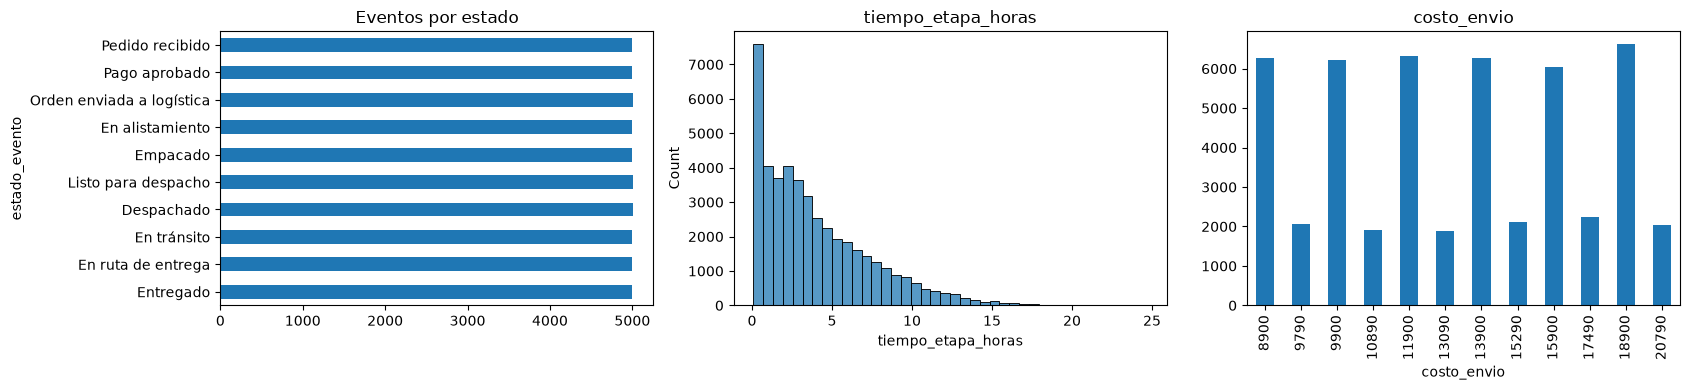

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
df_logistica["estado_evento"].value_counts().reindex(ORDEN_ESTADOS).plot.barh(ax=ax[0], title="Eventos por estado"); ax[0].invert_yaxis()
sns.histplot(df_logistica["tiempo_etapa_horas"].dropna(), bins=40, ax=ax[1]); ax[1].set_title("tiempo_etapa_horas")
df_logistica["costo_envio"].value_counts().sort_index().plot.bar(ax=ax[2], title="costo_envio"); plt.tight_layout(); plt.show()

## PARTE 6 — Preguntas de negocio (sobre los datos originales)

In [16]:
fcol = next((c for c in df_ventas.columns if "fecha" in c.lower()), None)
V, L = df_ventas, df_logistica
print("P1. ¿Qué ciudad vende más (valor neto)?");               display(V.groupby("ciudad")["valor_neto"].sum().sort_values(ascending=False))
print("P2. ¿Qué canal genera más ingresos y cuál tiene mayor ticket promedio?"); display(V.groupby("canal")["valor_neto"].agg(["sum", "mean", "count"]))
print("P3. ¿Qué categoría tiene mayor valor neto?");            display(V.groupby("categoria")["valor_neto"].sum().sort_values(ascending=False))
print("P4. ¿Qué % del valor bruto se pierde en descuentos, por categoría?"); display((V.groupby("categoria")["valor_descuento"].sum() / V.groupby("categoria")["valor_bruto"].sum() * 100).round(2))
print("P5. ¿Cuál es la calificación promedio por canal?");      display(V.groupby("canal")["calificacion_cliente"].agg(["mean", "count"]))
if fcol: 
    print("P6. ¿Cómo evolucionan las ventas por mes?");         display(V.assign(m=pd.to_datetime(V[fcol], errors="coerce").dt.to_period("M")).groupby("m")["valor_neto"].agg(["sum", "count"]))
print("P7. ¿Qué transportadora acumula más incidencias (y qué % de sus eventos)?")
d = L.dropna(subset=["transportadora"]).assign(inc=L["incidencia"].notna()); display(d.groupby("transportadora")["inc"].agg(["sum", "mean"]).sort_values("sum", ascending=False))
print("P8. ¿Qué etapa del proceso tarda más en promedio?");     display(L.groupby("estado_evento")["tiempo_etapa_horas"].mean().sort_values(ascending=False).round(2))
print("P9. ¿Cuál es el costo de envío promedio por ciudad?");   display(L.drop_duplicates().groupby("ciudad_destino")["costo_envio"].mean().round(0).sort_values(ascending=False))
print("P10. ¿Qué % de pedidos se entregó después de la fecha prometida?")
e = L.drop_duplicates(); e = e[e["estado_evento"] == "Entregado"]
tarde = pd.to_datetime(e["fecha_evento"]) > pd.to_datetime(e["fecha_prometida_entrega"]); print(f"{tarde.mean()*100:.2f}% de {len(e)} entregas")

P1. ¿Qué ciudad vende más (valor neto)?


ciudad
Bogotá D.C.     1.033662e+09
Cali            6.161808e+08
Medellín        5.876038e+08
Bucaramanga     3.478731e+08
Barranquilla    3.374398e+08
Pereira         2.457158e+08
Name: valor_neto, dtype: float64

P2. ¿Qué canal genera más ingresos y cuál tiene mayor ticket promedio?


,sum,mean,count
canal,,,
Aplicación móvil,9.262807e+08,625442.711006,1481
Página web,1.286922e+09,637090.101485,2020
Tienda física,9.552724e+08,637273.128753,1499


P3. ¿Qué categoría tiene mayor valor neto?


...

P8. ¿Qué etapa del proceso tarda más en promedio?


estado_evento
En tránsito                  9.01
En ruta de entrega           7.92
Entregado                    6.12
Empacado                     4.34
Listo para despacho          2.89
Despachado                   2.89
En alistamiento              1.80
Orden enviada a logística    0.72
Pago aprobado                0.36
Pedido recibido               NaN
Name: tiempo_etapa_horas, dtype: float64

P9. ¿Cuál es el costo de envío promedio por ciudad?


ciudad_destino
Cali            13774.0
Pereira         13683.0
Bogotá D.C.     13665.0
Medellín        13482.0
Bucaramanga     13476.0
Barranquilla    13436.0
Name: costo_envio, dtype: float64

P10. ¿Qué % de pedidos se entregó después de la fecha prometida?
17.13% de 4990 entregas


## PARTE 7 — Transformación (Medallion)
- **Bronze**: datos crudos tal como llegaron (`data/bronze/`).
- **Silver**: datos limpios y estandarizados → `df_ventas_transformado`, `df_logistica_transformado` (`data/silver/`).
- **Gold**: tabla integrada por `pedido_id` lista para análisis (`data/gold/pedidos_gold.csv`).

Cada decisión de imputación queda explicada en el DataFrame `decisiones` y en `reports/decisiones_transformacion.csv`.

In [17]:
dec = Decisiones()
df_ventas_transformado = silver_ventas(df_ventas, dec)
df_logistica_transformado = silver_logistica(df_logistica, dec, df_ventas_transformado.set_index("pedido_id")["fecha_venta"])
df_ventas_transformado.to_csv(ruta(cfg, "silver", "ventas_silver.csv"), index=False)
df_logistica_transformado.to_csv(ruta(cfg, "silver", "logistica_silver.csv"), index=False)
df_gold = gold_pedidos(df_ventas_transformado, df_logistica_transformado, dec)
df_gold.to_csv(ruta(cfg, "gold", "pedidos_gold.csv"), index=False)
decisiones = dec.df(); decisiones.to_csv(ruta(cfg, "reportes", "decisiones_transformacion.csv"), index=False, encoding="utf-8-sig")
print("Silver ventas:", df_ventas_transformado.shape, "| Silver logística:", df_logistica_transformado.shape, "| Gold:", df_gold.shape)

Silver ventas: (5000, 19) | Silver logística: (49900, 13) | Gold: (5000, 40)


### 7.1 Decisiones de limpieza (problema → cuantificación → acción → justificación)

In [18]:
with pd.option_context("display.max_colwidth", 110, "display.max_rows", 200):
    display(decisiones)

,tabla,columna,problema,registros_afectados,accion,justificacion
0,ventas,fecha_venta,Fecha como texto/objeto,5000,Convertir a datetime (inválidas -> NaT),Permite filtrar y calcular periodos
1,ventas,id_tienda,Nulo en canales digitales (web / app): no hay tienda asociada,3501,Reemplazar por 'NO APLICA',El nulo es estructural; se rotula para poder agrupar y filtrar
2,ventas,calificacion_cliente,Nulo: el cliente no calificó,2172,Mantener nulo,Ausencia de calificación es información válida; imputar sesgaría la satisfacción
3,logistica,Unnamed: 13,"Columna sin nombre con una fórmula residual de Excel (=AI(""""))",1,Eliminar columna,"No pertenece al modelo de datos; 99,998% nula"
4,logistica,(fila completa),Filas completamente duplicadas,99,drop_duplicates(),Un evento no puede registrarse dos veces con el mismo contenido
5,logistica,evento_id,evento_id repetido con contenido diferente,1,Conservar la fila con menos nulos,evento_id debe ser único; la fila más completa es la más confiable
6,logistica,"fecha_evento, fecha_prometida_entrega",Fechas leídas como texto,49900,Convertir a datetime,Permite cálculos de tiempo y rangos
7,logistica,ciudad_destino,Nulo accidental (el atributo existe en otros eventos del mismo pedido),45,Imputar con el valor del mismo pedido_id,El destino es único por pedido (verificado: 0 pedidos con valores distintos)
8,logistica,centro_logistico,Nulo accidental (el atributo existe en otros eventos del mismo pedido),89,Imputar con el valor del mismo pedido_id,El CEDI es único por pedido (verificado: 0 pedidos con valores distintos)
9,logistica,fecha_prometida_entrega,Nulo accidental (el atributo existe en otros eventos del mismo pedido),55,Imputar con el valor del mismo pedido_id,La fecha prometida es única por pedido (verificado: 0 pedidos con valores distintos)


### 7.2 Antes vs después

In [19]:
comp = pd.DataFrame({
    "filas_antes": [len(df_ventas), len(df_logistica)], "filas_despues": [len(df_ventas_transformado), len(df_logistica_transformado)],
    "nulos_antes": [int(df_ventas.isna().sum().sum()), int(df_logistica.isna().sum().sum())],
    "nulos_despues": [int(df_ventas_transformado.isna().sum().sum()), int(df_logistica_transformado.isna().sum().sum())],
    "duplicados_antes": [int(df_ventas.duplicated().sum()), int(df_logistica.duplicated().sum())],
    "duplicados_despues": [int(df_ventas_transformado.duplicated().sum()), int(df_logistica_transformado.duplicated().sum())],
}, index=["ventas", "logistica"]); display(comp)
display(pf.perfil_nulos(df_logistica_transformado).query("nulos > 0"))

,filas_antes,filas_despues,nulos_antes,nulos_despues,duplicados_antes,duplicados_despues
ventas,5000,5000,5673,2172,0,0
logistica,50000,49900,213176,64879,99,0


,nulos,porcentaje
transportadora,29944,60.01
numero_guia,29944,60.01
tiempo_etapa_horas,4991,10.00


**Nulos que se mantienen a propósito (tienen interpretación válida):** `transportadora`/`numero_guia` antes del despacho, `tiempo_etapa_horas` en "Pedido recibido" y `calificacion_cliente` cuando el cliente no calificó.

### 7.3 Validación cruzada entre fuentes (Gold)

In [20]:
print("Pedidos ventas:", df_ventas_transformado["pedido_id"].nunique(), "| pedidos logística:", df_logistica_transformado["pedido_id"].nunique())
print("Pedidos sin contraparte:", len(set(df_ventas_transformado.pedido_id) ^ set(df_logistica_transformado.pedido_id)))
print("Ciudad de venta != ciudad destino:", int((df_gold["ciudad"] != df_gold["ciudad_destino"]).sum()))
print("Pedidos sin evento 'Pedido recibido':", int((df_gold["n_estados_distintos"] < 10).sum()), "(incompletos:", int((~df_gold["pedido_completo"]).sum()), ")")
display(df_gold.groupby("transportadora")["entrega_a_tiempo"].mean().round(3).to_frame("% entrega a tiempo"))

Pedidos ventas: 5000 | pedidos logística: 5000
Pedidos sin contraparte: 0
Ciudad de venta != ciudad destino: 0
Pedidos sin evento 'Pedido recibido': 98 (incompletos: 98 )


,% entrega a tiempo
transportadora,
Coordinadora,0.830
Envia,0.835
Inter Rapidísimo,0.825
Servientrega,0.830
TCC,0.821


In [21]:
print("Pedidos entregados a tiempo vs tarde (Gold):"); display(df_gold["entrega_a_tiempo"].value_counts(dropna=False))
print("Pedidos con ciclo incompleto (<10 estados):", (~df_gold["pedido_completo"]).sum())
display(df_gold.head())

Pedidos entregados a tiempo vs tarde (Gold):


entrega_a_tiempo
1.0    4135
0.0     855
NaN      10
Name: count, dtype: int64

Pedidos con ciclo incompleto (<10 estados): 98


,id_venta,pedido_id,fecha_venta,id_cliente,ciudad,canal,id_tienda,categoria,producto,cantidad,precio_unitario,descuento_pct,valor_bruto,valor_descuento,valor_neto,medio_pago,calificacion_cliente,flag_neto_inconsistente,flag_bruto_inconsistente,n_eventos,n_estados_distintos,fecha_primer_evento,fecha_ultimo_evento,horas_totales_proceso,n_incidencias,centro_logistico,ciudad_destino,transportadora,numero_guia,costo_envio,fecha_prometida_entrega,estado_final,fecha_entrega,entregado,entrega_a_tiempo,dias_hasta_entrega,pedido_completo,valor_neto_mas_envio,pct_envio_sobre_neto,mes_venta
0,1,PED000001,2026-01-18 22:06:15,CLI00011,Bogotá D.C.,Aplicación móvil,NO APLICA,Deportes,Banda caminadora,1,2199900.0,10.0,2199900.0,219990.0,1979910.0,Tarjeta crédito,NaN,False,False,10,10,2026-01-18 22:06:15,2026-01-20 14:18:58,40.20,0,CEDI Bogotá,Bogotá D.C.,TCC,KMS20283624,8900,2026-01-20 14:06:15,Entregado,2026-01-20 14:18:58,True,0.0,1.675498,True,1988810.0,0.45,2026-01
1,2,PED000002,2026-04-25 21:07:01,CLI00802,Cali,Página web,NO APLICA,Deportes,Mancuernas ajustables,1,399900.0,10.0,399900.0,39990.0,359910.0,Tarjeta crédito,NaN,False,False,10,10,2026-04-25 21:07:01,2026-04-27 11:00:48,37.89,0,CEDI Cali,Cali,Envia,KMS11084230,8900,2026-04-27 21:07:01,Entregado,2026-04-27 11:00:48,True,1.0,1.579016,True,368810.0,2.47,2026-04
2,3,PED000003,2026-03-28 02:39:43,CLI00255,Medellín,Página web,NO APLICA,Tecnología,Tablet 10 pulgadas,1,899900.0,10.0,899900.0,89990.0,809910.0,Tarjeta crédito,4.0,False,False,10,10,2026-03-28 02:39:43,2026-03-29 22:55:26,44.26,0,CEDI Medellín,Medellín,Inter Rapidísimo,KMS39135059,13900,2026-03-30 00:39:43,Entregado,2026-03-29 22:55:26,True,1.0,1.844248,True,823810.0,1.72,2026-03
3,4,PED000004,2026-04-30 12:35:40,CLI00383,Medellín,Aplicación móvil,NO APLICA,Electrodomésticos,Freidora de aire,2,472400.0,15.0,944800.0,141720.0,803080.0,PSE,5.0,False,False,10,10,2026-04-30 12:35:40,2026-05-03 08:20:40,67.75,0,CEDI Medellín,Medellín,Envia,KMS32561389,13900,2026-05-02 10:35:40,Entregado,2026-05-03 08:20:40,True,0.0,2.822917,True,816980.0,1.73,2026-04
4,5,PED000005,2026-04-04 00:18:12,CLI01286,Bogotá D.C.,Aplicación móvil,NO APLICA,Deportes,Balón fútbol,1,119900.0,0.0,119900.0,0.0,119900.0,Tarjeta crédito,NaN,False,False,10,10,2026-04-04 00:18:12,2026-04-05 08:43:56,32.43,0,CEDI Bogotá,Bogotá D.C.,Coordinadora,KMS90585430,8900,2026-04-05 16:18:12,Entregado,2026-04-05 08:43:56,True,1.0,1.351204,True,128800.0,7.42,2026-04


## PARTE 8 — Automatización con `schedule`
El orquestador está en `scheduler.py`; ejecuta `etl.pipeline.ejecutar_pipeline()` todos los días a la hora definida en `config.yaml`, registra todo en `logs/etl.log` y, si una ejecución falla, registra el error pero **el orquestador sigue vivo**.

```bash
python scheduler.py --una-vez   # prueba: corre el ETL una vez
python scheduler.py             # queda programado (diario, 02:00)
```

In [22]:
# Demostración: misma función que el scheduler
import schedule
from etl.pipeline import ejecutar_pipeline
schedule.clear(); schedule.every().day.at(cfg["scheduler"]["hora_diaria"]).do(lambda: ejecutar_pipeline(cfg))
print("Próxima ejecución programada:", schedule.next_run()); schedule.clear()

Próxima ejecución programada: 2026-10-06 02:00:00


## CONCLUSIONES

**HALLAZGOS df_ventas**
1. **Estructura:** 5.000 registros y 17 variables; cada fila es una venta y hay 5.000 `id_venta` y 5.000 `pedido_id` únicos (1 pedido por venta). Periodo: 2026-01-01 a 2026-06-30. Hay 2.292 clientes distintos (un cliente compra varias veces).
2. **Duplicados:** 0 filas duplicadas y 0 identificadores repetidos; la fuente comercial es la más limpia de las dos.
3. **Nulos:** `id_tienda` 70,0% (nulo **estructural**: solo existe en tienda física; se rotula `NO APLICA`) y `calificacion_cliente` 43,4% (el cliente no calificó; se conserva nulo porque imputar sesgaría la satisfacción).
4. **Consistencia aritmética:** `valor_bruto = cantidad × precio_unitario`, `valor_descuento = bruto × descuento_pct` y `valor_neto = bruto − descuento` se cumplen en el 100% de las filas. Cada producto aparece con 5 precios unitarios distintos (a revisar con comercial: listas de precios o variaciones).
5. **Distribuciones:** Bogotá 33,1% de las ventas; web 40,4%; Tecnología lidera en número de ventas pero Deportes en valor neto; 67% de las ventas es de 1 unidad; `valor_neto` sesgado (media ≈ 634 mil vs mediana ≈ 367 mil).
6. **Categorías:** ciudad, canal, categoría y medio de pago ya venían estandarizados (0 variantes de escritura); la mayor parte del pago es con tarjeta de crédito (37,8%) y PSE (24,5%).
7. **Transformación:** 0 filas eliminadas, 0 imputaciones numéricas; solo se rotuló `id_tienda` y se añadieron banderas de consistencia (0 casos marcados).

In [23]:
# Verificación numérica de los hallazgos de ventas (se calcula sobre los datos cargados)
v, vt = df_ventas, df_ventas_transformado
print("Registros / pedidos únicos:", len(v), v["pedido_id"].nunique(), "| duplicados:", int(v.duplicated().sum()))
print("Nulos %:", pf.perfil_nulos(v).query("nulos > 0")["porcentaje"].to_dict())
print("Ciudad top:", v["ciudad"].value_counts(normalize=True).round(4).head(1).to_dict())
print("bruto != cant*precio:", int(((v.cantidad * v.precio_unitario - v.valor_bruto).abs() > 1).sum()),
      "| neto != bruto-desc:", int(((v.valor_bruto - v.valor_descuento - v.valor_neto).abs() > 1).sum()))
print("Precios distintos por producto:", v.groupby("producto")["precio_unitario"].nunique().unique())
print("Filas Silver:", len(vt), "| id_tienda NO APLICA:", int((vt["id_tienda"] == "NO APLICA").sum()))

Registros / pedidos únicos: 5000 5000 | duplicados: 0
Nulos %: {'id_tienda': 70.02, 'calificacion_cliente': 43.44}
Ciudad top: {'Bogotá D.C.': 0.3306}
bruto != cant*precio: 0 | neto != bruto-desc: 0
Precios distintos por producto: [5]
Filas Silver: 5000 | id_tienda NO APLICA: 3501


**HALLAZGOS df_logistica**
1. **Estructura:** 50.000 eventos × 14 columnas para 5.000 pedidos (~10 eventos por pedido, 10 estados del ciclo). Rango: 2026-01-01 a 2026-07-03.
2. **Columna basura:** `Unnamed: 13` con una fórmula residual de Excel (`=AI("")`) en una sola fila → eliminada en Silver.
3. **Duplicados:** 99 filas completamente duplicadas (0,2%) y 100 `evento_id` repetidos (99 copias exactas + 1 con datos incompletos) → 49.900 eventos únicos. Consecuencia: 98 pedidos quedaron con el ciclo incompleto (8 o 9 de 10 estados) y 10 sin evento "Entregado".
4. **Nulos:** `incidencia` 98,98% y `observacion` 96,55% (normales: no hubo novedad); `transportadora`/`numero_guia` ~60% (normales antes del despacho; 140 filas anómalas después: 80 sin transportadora y 60 sin guía); `tiempo_etapa_horas` 10% (= primer evento de cada pedido); `centro_logistico` 0,18%, `fecha_evento` 0,13%, `fecha_prometida_entrega` 0,11% y `ciudad_destino` 0,09% son errores recuperables.
5. **Tipos:** las dos columnas de fecha se leen como texto; los identificadores y el resto de tipos son coherentes.
6. **Cardinalidad:** `costo_envio` solo tiene 12 valores y **no depende de la ciudad** (promedios de ~13.500 en las 6 ciudades). Los valores terminados en 90 (9.790, 10.890, 13.090, 15.290, 17.490, 20.790) son exactamente +10% sobre las tarifas base → ~25% de los pedidos tiene un recargo.
7. **Negocio:** solo ~1% de los eventos tiene incidencia (511; la más frecuente "Error de clasificación", 98) y ~17% de los pedidos se entrega después de la fecha prometida. La etapa más lenta es "En tránsito" (≈9 h promedio por evento).

**HALLAZGOS DE LA TRANSFORMACIÓN**
- **Bronze** conserva los datos originales; **Silver** deja 0 duplicados, fechas en `datetime` y categorías estandarizadas; **Gold** integra ventas + logística por `pedido_id` (una fila por pedido) con métricas nuevas: `n_eventos`, `horas_totales_proceso`, `estado_final`, `fecha_entrega`, `entrega_a_tiempo`, `dias_hasta_entrega`, `n_incidencias`, `pedido_completo`.
- Las 65 `fecha_evento` nulas se **reconstruyeron**: 10 (eventos 'Pedido recibido') con la `fecha_venta` del mismo pedido y el resto con la fecha del evento anterior + `tiempo_etapa_horas` (en lugar de media/mediana, que habrían inventado fechas). Así los 4.990 pedidos con evento de entrega tienen fecha de entrega calculable.
- Los atributos fijos por pedido (ciudad, CEDI, fecha prometida, transportadora, guía) se recuperaron desde otros eventos del **mismo pedido**; los nulos con significado de negocio se conservaron o se rotularon (`SIN INCIDENCIA`, `SIN OBSERVACIÓN`) y **no se imputó nada de forma automática**.
- **Validación cruzada:** las dos fuentes son coherentes (los 5.000 `pedido_id` cruzan 1 a 1 y la ciudad de la venta coincide con la de destino en el 100%). 98 pedidos no tienen el ciclo completo de 10 estados (96 con 9 y 2 con 8) y 10 no tienen evento 'Entregado'; el 82,9% de las entregas cumple la fecha prometida y el desempeño es muy parecido entre transportadoras (82-83,5%).